# Exercício 3

Considere o problema primal linear

$$
\min \; f(x) = 2x_1 + x_2 + 4x_3
$$

sujeito a

$$
\begin{aligned}
-2x_1 + x_2 + x_3 &\geq 1,\\
-x_1 + 2x_2 - x_3 &\leq 1,\\
x_1, x_2, x_3 &\geq 0.
\end{aligned}
$$

Solucione o problema linear em questão por meio das relações de dualidade.

In [2]:
import sympy as sp
from sympy.plotting import plot_implicit

In [3]:
x1, x2, x3 = sp.symbols('x_1 x_2 x_3', real=True)

In [6]:
f = 2*x1 + x2 + 4*x3

In [7]:
restricoes = sp.And(
    -2*x1 + x2 + x3 >= 1,
    -x1 + 2*x2 - x3 <= 1,
    x1 >= 0,
    x2 >= 0,
    x3 >= 0
)

In [8]:
A = sp.Matrix([
    [-2,  1, 1],
    [ 1, -2, 1]
])

b = sp.Matrix([
    1,
   -1
])

c = sp.Matrix([
    2,
    1,
    4
])

A, b, c

(Matrix([
 [-2,  1, 1],
 [ 1, -2, 1]]),
 Matrix([
 [ 1],
 [-1]]),
 Matrix([
 [2],
 [1],
 [4]]))

In [9]:
A_dual = A.T
c_dual = b
b_dual = c

A_dual, c_dual, b_dual

(Matrix([
 [-2,  1],
 [ 1, -2],
 [ 1,  1]]),
 Matrix([
 [ 1],
 [-1]]),
 Matrix([
 [2],
 [1],
 [4]]))

In [11]:
y1, y2 = sp.symbols('y_1 y_2', real=True)

In [12]:
restricoes_dual = sp.And(
    -2*y1 + y2 <= 2,
    y1 - 2*y2 <= 1,
    y1 + y2 <= 4,
    y1 >= 0,
    y2 >= 0
)

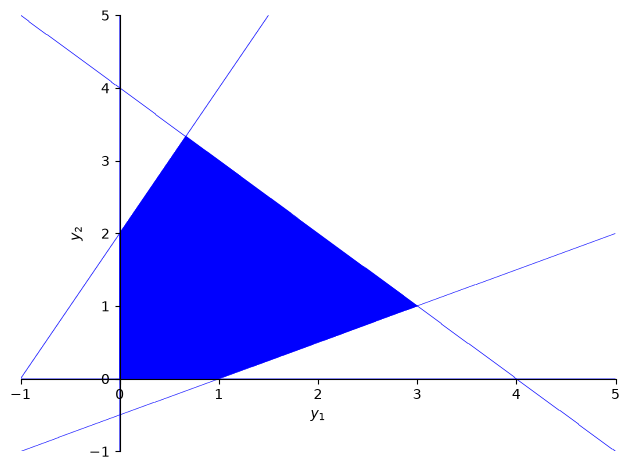

In [13]:
p_dual = plot_implicit(
    restricoes_dual,
    (y1, -1, 5),
    (y2, -1, 5),
    show=False
)

retas_dual = [
    sp.Eq(-2*y1 + y2, 2),
    sp.Eq(y1 - 2*y2, 1),
    sp.Eq(y1 + y2, 4),
    sp.Eq(y1, 0),
    sp.Eq(y2, 0)
]

for reta in retas_dual:
    grafico_reta = plot_implicit(
        reta,
        (y1, -1, 5),
        (y2, -1, 5),
        show=False
    )
    p_dual.extend(grafico_reta)

p_dual.show()

**### Relações de complementaridade**

A solução ótima do dual obtida graficamente é

$$
y^* = (3,1)^T.
$$

Pelas condições de complementaridade:

- se uma restrição do dual possui folga positiva, a variável primal correspondente é nula;
- se uma variável dual é positiva, a restrição primal correspondente é ativa.

In [14]:
y_otimo = {
    y1: 3,
    y2: 1
}

folgas_dual = [
    2 - (-2*y1 + y2),
    1 - (y1 - 2*y2),
    4 - (y1 + y2)
]

folgas_dual_otimo = [
    sp.simplify(folga.subs(y_otimo))
    for folga in folgas_dual
]

folgas_dual_otimo

[7, 0, 0]

As folgas das três restrições duais são

$$
(7,0,0).
$$

A primeira restrição dual possui folga positiva. Como ela corresponde à variável primal $x_1$, pela complementaridade,

$$
x_1 = 0.
$$

As demais restrições duais estão ativas.

Como

$$
y_1 > 0
\qquad\text{e}\qquad
y_2 > 0,
$$

as duas restrições do primal devem ser satisfeitas como igualdades:

$$
\begin{aligned}
-2x_1+x_2+x_3 &= 1,\\
x_1-2x_2+x_3 &= -1.
\end{aligned}
$$

Além disso, já sabemos que

$$
x_1=0.
$$

In [15]:
solucao_primal = sp.solve(
    [
        sp.Eq(-2*x1 + x2 + x3, 1),
        sp.Eq(x1 - 2*x2 + x3, -1),
        sp.Eq(x1, 0)
    ],
    [x1, x2, x3],
    dict=True
)

solucao_primal

[{x_1: 0, x_2: 2/3, x_3: 1/3}]

In [16]:
x_otimo = solucao_primal[0]

f_otimo = sp.simplify(f.subs(x_otimo))

f_otimo

2

In [17]:
g = y1 - y2

g_otimo = sp.simplify(g.subs(y_otimo))

f_otimo, g_otimo

(2, 2)

Portanto,

$$
\boxed{
x^*=
\left(
0,\frac{2}{3},\frac{1}{3}
\right)^T
}
$$

e

$$
\boxed{f(x^*)=2}.
$$

Para o dual,

$$
\boxed{y^*=(3,1)^T}
$$

e

$$
\boxed{g(y^*)=2}.
$$

Assim,

$$
\boxed{f(x^*)=g(y^*)=2},
$$

confirmando a dualidade forte.